In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [3]:
path_rcal_lar2023 = "/Users/jcapo/cernbox/RTDdata/calib/LARTGRAD_TREE_rcal.json"
path_lar2023 = "/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2023/lar2023_tree_method_avg_path.pkl"
path_rcal_ln22 = "/Users/jcapo/cernbox/RTDdata/calib/LN22TGRAD_TREE_rcal.json"
path_ln22 = "/Users/jcapo/cernbox/RTDdata/calib/TGrad/LN2022/ln2022_tree_method_avg_path.pkl"
path_rcal_ln23 = "/Users/jcapo/cernbox/RTDdata/calib/LN23TGRAD_TREE_rcal.json"
path_ln23 = "/Users/jcapo/cernbox/RTDdata/calib/TGrad/LN2023/ln2023_tree_method_avg_path.pkl"
path_lar2018 = "/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2018/lar2018_ref_method.pkl"

In [4]:
import pandas as pd

data = [
    [39607, 12.4887, 12.4887],
    [39608, -2.35262, -2.35262],
    [39609, 5.97094, 5.97094],
    [39610, -0.05715, -0.05715],
    [39611, -27.9827, -27.9827],
    [39612, 16.8911, 16.8911],
    [39613, 8.18468, 8.18468],
    [39614, -11.2614, -11.2614],
    [39615, -2.87244, -2.87244],
    [39619, -11.3329, -11.3329],
    [39620, 41.0086, 41.0086],
    [39621, 32.0975, 32.0975],
    [39622, -4.03162, -4.03162],
    [39623, 0.19726, 0.19726],
    [39624, -25.9406, -25.9406],
    [39625, 1.66196, 1.66196],
    [39626, 25.5046, 25.5046],
    [39627, 19.2767, 19.2767],
    [39644, -21.516, -21.516],
    [39645, -25.1143, -25.1143],
    [39646, -16.9895, -16.9895],
    [39647, -35.8349, -35.8349],
    [39648, -18.3138, -18.3138],
    [39649, -9.04, -9.04],
    [39628, -8.082, -8.082],
    [39629, 29.4053, 29.4053],
    [39630, -22.2924, -22.2924],
    [39657, 1.29244, -2.20855],
    [39658, -9.58999, -13.091],
    [39659, -23.3865, -26.8875],
    [39664, 32.3776, 28.8766],
    [39665, 14.2715, 10.7705],
    [39666, -13.0897, -16.5907],
    [39660, 18.3025, 14.8015],
    [39661, -1.35034, -4.85132],
    [39667, 42.4804, 38.9794],
    [39650, 9.92492, 6.42393],
    [39651, 35.7309, 32.2299],
    [39652, -17.6804, -21.1814],
    [39653, -32.6772, -36.1782],
    [39654, -8.80314, -12.3041],
    [39655, -5.63915, -9.14014],
    [40524, 6.53055, 3.02956],
    [40525, 37.5954, 34.0944],
    [40526, 21.8345, 18.3335],
    [40531, 15.2934, 11.7925],
    [40532, 25.0856, 21.5847],
    [40533, 21.9468, 18.4459],
]

df = pd.DataFrame(data, columns=["CAL-ID", "cc_2018_1", "cc_2018_2"])
df.set_index("CAL-ID", inplace=True)
df["cc_2018_1"] = df["cc_2018_1"] - df["cc_2018_1"].loc[40525]
df["cc_2018_2"] = df["cc_2018_2"] - df["cc_2018_2"].loc[40525]
lar2018_alt = df.copy()


In [5]:
import json

with open(path_rcal_lar2023, "r") as f:
    rlar2023 = json.load(f)

with open(path_lar2023, "rb") as f:
    lar2023_avg = pickle.load(f)["40525"]

with open(path_rcal_ln22, "r") as f:
    rln22 = json.load(f)

with open(path_ln22, "rb") as f:
    ln22_avg = pickle.load(f)["40525"]

with open(path_rcal_ln23, "r") as f:
    rln23 = json.load(f)

with open(path_ln23, "rb") as f:
    ln23_avg = pickle.load(f)["40525"]

with open(path_lar2018, "rb") as f:
    lar2018_avg = pickle.load(f)["40525"]

In [6]:
rlar2023_avg = {}
for sens_id, values in rlar2023["40525"].items():
    rlar2023_avg[sens_id] = np.mean(values)
rln22_avg = {}
for sens_id, values in rln22["40525"].items():
    rln22_avg[sens_id] = np.mean(values)
rln23_avg = {}
for sens_id, values in rln23["40525"].items():
    rln23_avg[sens_id] = np.mean(values)


In [7]:
rlar2023_avg = pd.DataFrame(rlar2023_avg, index=[0]).T
rln22_avg = pd.DataFrame(rln22_avg, index=[0]).T
rln23_avg = pd.DataFrame(rln23_avg, index=[0]).T

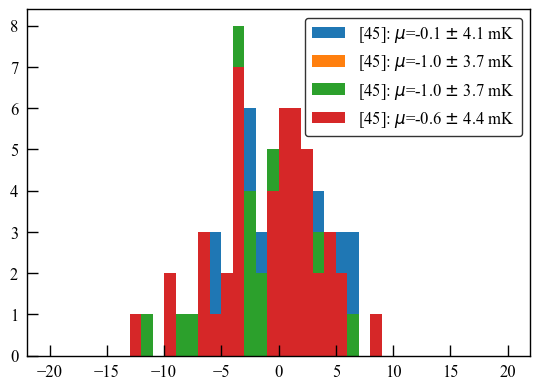

In [8]:
diff = (ln22_avg["cc"] - lar2023_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
plt.hist(diff, range=(-20,20), bins=40, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")

diff = (ln23_avg["cc"] - lar2023_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
plt.hist(diff, range=(-20,20), bins=40, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
plt.legend()

diff = ((ln23_avg["cc"] + rln23_avg[0]) - (lar2023_avg["cc"] + rlar2023_avg[0])).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
plt.hist(diff, range=(-20,20), bins=40, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")

diff = ((lar2018_avg["cc"]) - (lar2023_avg["cc"] - rlar2023_avg[0])).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
plt.hist(diff, range=(-20,20), bins=40, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
plt.legend()

Text(0, 0.5, 'Counts')

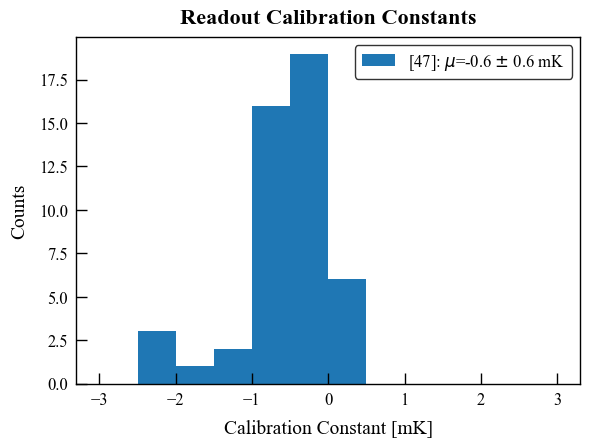

In [9]:
plt.hist(rlar2023_avg[0], range=(-3,3), bins=12, label=fr"[{len(rlar2023_avg[0])}]: $\mu$={np.mean(rlar2023_avg[0]):.1f} $\pm$ {np.std(rlar2023_avg[0]):.1f} mK")
# plt.hist(rln22_avg[0], range=(-3,3), bins=12, fill=False, edgecolor='orange', linewidth=3, label=fr"[{len(rln22_avg[0])}]: $\mu$={np.mean(rln22_avg[0]):.1f} $\pm$ {np.std(rln22_avg[0]):.1f} mK")
plt.legend()
plt.title("Readout Calibration Constants")
plt.xlabel("Calibration Constant [mK]")
plt.ylabel("Counts")

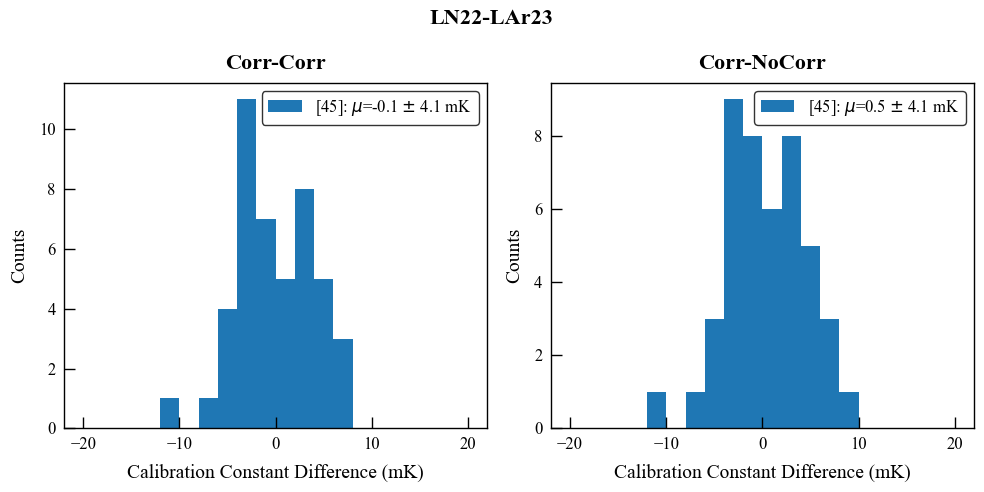

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
diff = (ln22_avg["cc"] - lar2023_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[0].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[0].legend()

diff = (ln22_avg["cc"] - (lar2023_avg["cc"] + rlar2023_avg[0])).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[1].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[1].legend()

fig.suptitle("LN22-LAr23", fontsize=16, fontweight='bold')
axes[0].set_title("Corr-Corr")
axes[0].set_xlabel("Calibration Constant Difference (mK)")
axes[0].set_ylabel("Counts")
axes[1].set_title("Corr-NoCorr")
axes[1].set_xlabel("Calibration Constant Difference (mK)")
axes[1].set_ylabel("Counts")

fig.tight_layout()

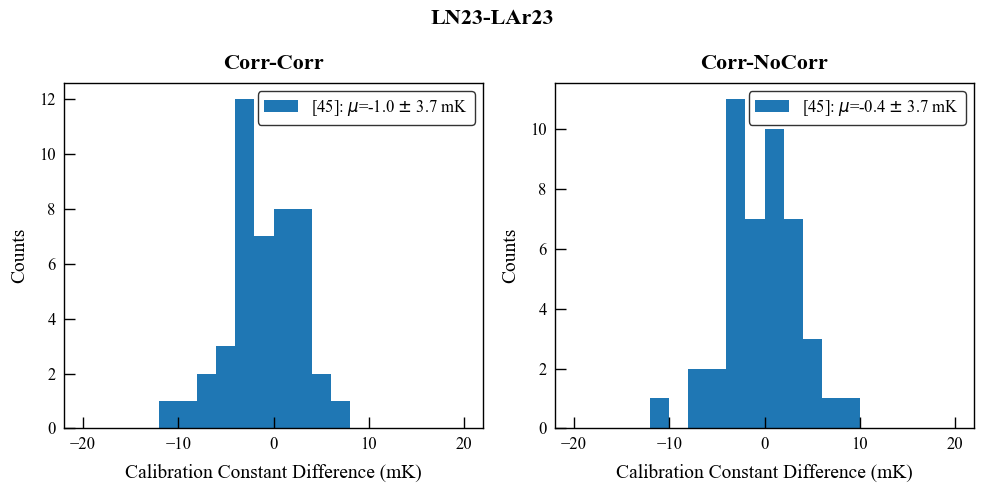

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
diff = (ln23_avg["cc"] - lar2023_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[0].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[0].legend()

diff = (ln23_avg["cc"] - (lar2023_avg["cc"] + rlar2023_avg[0])).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[1].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[1].legend()

fig.suptitle("LN23-LAr23", fontsize=16, fontweight='bold')
axes[0].set_title("Corr-Corr")
axes[0].set_xlabel("Calibration Constant Difference (mK)")
axes[0].set_ylabel("Counts")
axes[1].set_title("Corr-NoCorr")
axes[1].set_xlabel("Calibration Constant Difference (mK)")
axes[1].set_ylabel("Counts")

fig.tight_layout()

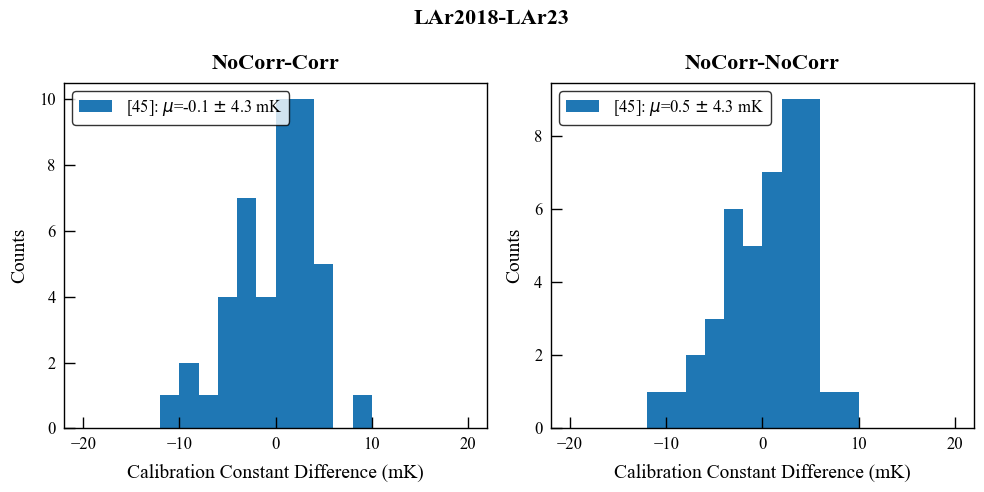

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
diff = (lar2018_avg["cc"] - lar2023_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[0].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[0].legend()

diff = (lar2018_avg["cc"] - (lar2023_avg["cc"] + rlar2023_avg[0])).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[1].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[1].legend()

fig.suptitle("LAr2018-LAr23", fontsize=16, fontweight='bold')
axes[0].set_title("NoCorr-Corr")
axes[0].set_xlabel("Calibration Constant Difference (mK)")
axes[0].set_ylabel("Counts")
axes[1].set_title("NoCorr-NoCorr")
axes[1].set_xlabel("Calibration Constant Difference (mK)")
axes[1].set_ylabel("Counts")

fig.tight_layout()

In [13]:
lar2018_alt.index = lar2018_alt.index.astype(int)
lar2023_avg.index = lar2023_avg.index.astype(int)
lar2018_avg.index = lar2018_avg.index.astype(int)
ln22_avg.index = ln22_avg.index.astype(int)
ln23_avg.index = ln23_avg.index.astype(int)

# df = lar2018_alt[["cc"]].join(
#     lar2023_avg[["cc", "cc_err"]],
#     lsuffix="_2018",
#     rsuffix="_2023",
#     how="inner"   # only overlapping CAL-ID
# )

# df["diff"] = df["cc_2018"] - df["cc_2023"]



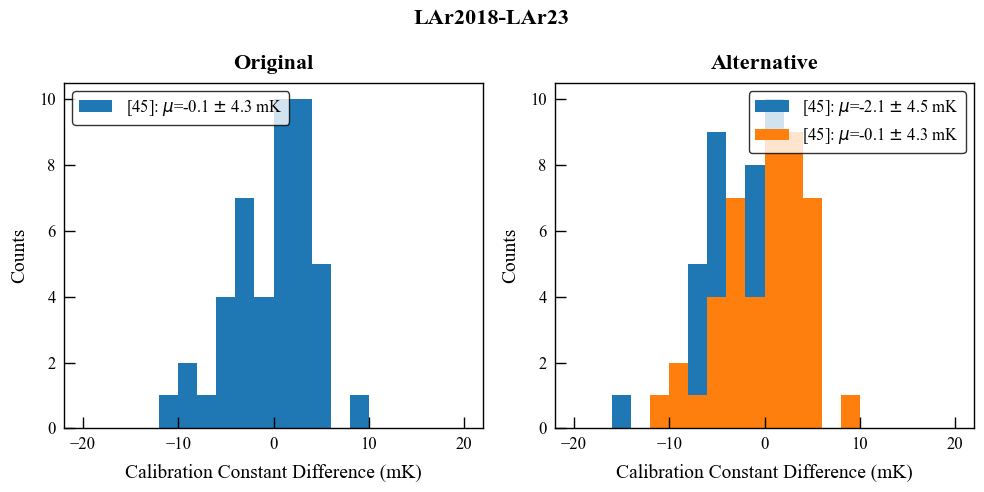

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
diff = (lar2018_avg["cc"] - lar2023_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[0].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[0].legend()

diff = (lar2018_alt["cc_2018_1"] - lar2023_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[1].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[1].legend()

diff = (lar2018_alt["cc_2018_2"] - lar2023_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[1].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[1].legend()

fig.suptitle("LAr2018-LAr23", fontsize=16, fontweight='bold')
axes[0].set_title("Original")
axes[0].set_xlabel("Calibration Constant Difference (mK)")
axes[0].set_ylabel("Counts")
axes[1].set_title("Alternative")
axes[1].set_xlabel("Calibration Constant Difference (mK)")
axes[1].set_ylabel("Counts")

fig.tight_layout()

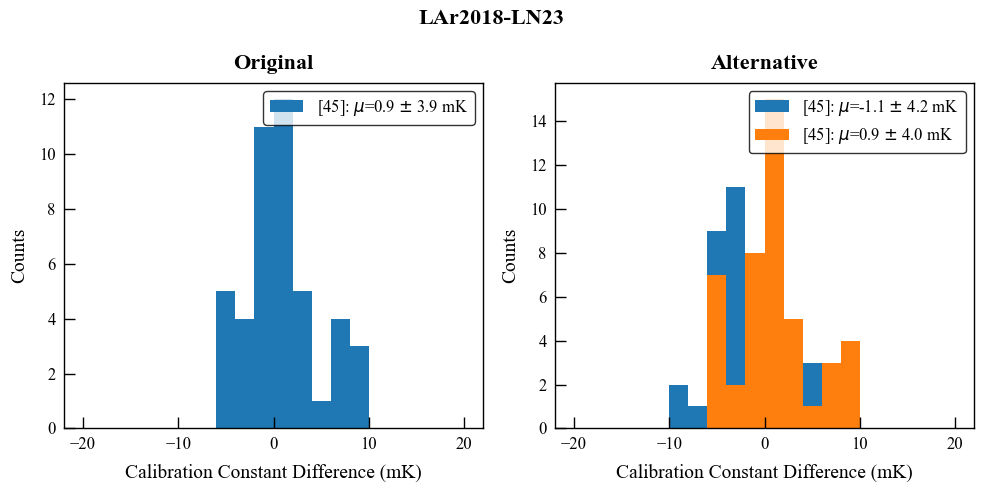

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
diff = (lar2018_avg["cc"] - ln23_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[0].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[0].legend()

diff = (lar2018_alt["cc_2018_1"] - ln23_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[1].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[1].legend()

diff = (lar2018_alt["cc_2018_2"] - ln23_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[1].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[1].legend()

fig.suptitle("LAr2018-LN23", fontsize=16, fontweight='bold')
axes[0].set_title("Original")
axes[0].set_xlabel("Calibration Constant Difference (mK)")
axes[0].set_ylabel("Counts")
axes[1].set_title("Alternative")
axes[1].set_xlabel("Calibration Constant Difference (mK)")
axes[1].set_ylabel("Counts")

fig.tight_layout()

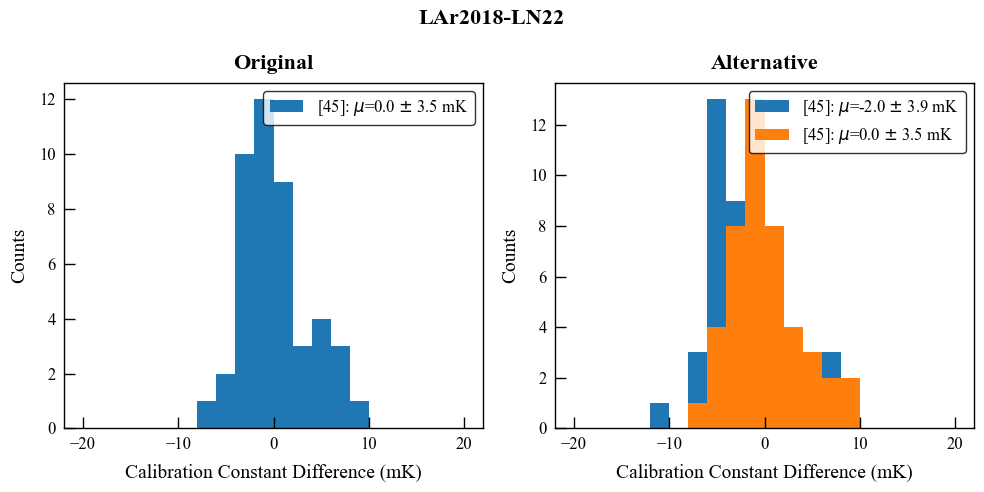

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
diff = (lar2018_avg["cc"] - ln22_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[0].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[0].legend()

diff = (lar2018_alt["cc_2018_1"] - ln22_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[1].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[1].legend()

diff = (lar2018_alt["cc_2018_2"] - ln22_avg["cc"]).dropna()
diff = diff[diff != 0.0]
mu = np.mean(diff)
sigma = np.std(diff)
axes[1].hist(diff, range=(-20,20), bins=20, label=fr"[{len(diff)}]: $\mu$={mu:.1f} $\pm$ {sigma:.1f} mK")
axes[1].legend()

fig.suptitle("LAr2018-LN22", fontsize=16, fontweight='bold')
axes[0].set_title("Original")
axes[0].set_xlabel("Calibration Constant Difference (mK)")
axes[0].set_ylabel("Counts")
axes[1].set_title("Alternative")
axes[1].set_xlabel("Calibration Constant Difference (mK)")
axes[1].set_ylabel("Counts")

fig.tight_layout()